In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optimal_policy import (
    Parameters, solve_optimal_policy, compute_outcomes,
    compute_welfare_vs_budget_allocation, compare_beta_distributions,
    compare_welfare_vs_budget_allocation, compute_mvpfs_along_frontier,
    plot_mvpf_decomposition,
)

                  COMPARISON ACROSS BELIEF VARIANCES                  
Mean belief: 1.00%

──────────────────────────────────────────────────────────────────────
Configuration 1: σ² = 0.000025
──────────────────────────────────────────────────────────────────────
  Beta parameters:      α = 3.95, β = 391.05

  WITHOUT INTERVENTION:
    Insurance threshold (q*): 1.01%
    Fraction insured:         42.6%
    Social welfare:           -1.015781

  OPTIMAL POLICY:
    Subsidy (s):              17.4%
    Relief (a):               0.0%
    Shadow value (λ):         2.229281

  OUTCOMES WITH OPTIMAL POLICY:
    Insurance threshold (q*): 0.83%
    Fraction insured:         57.4%
    Social welfare:           -1.013301
    Welfare gain:             0.002480

──────────────────────────────────────────────────────────────────────
Configuration 2: σ² = 0.000049
──────────────────────────────────────────────────────────────────────
  Beta parameters:      α = 2.01, β = 199.03

  WITHOUT INTERVENTIO

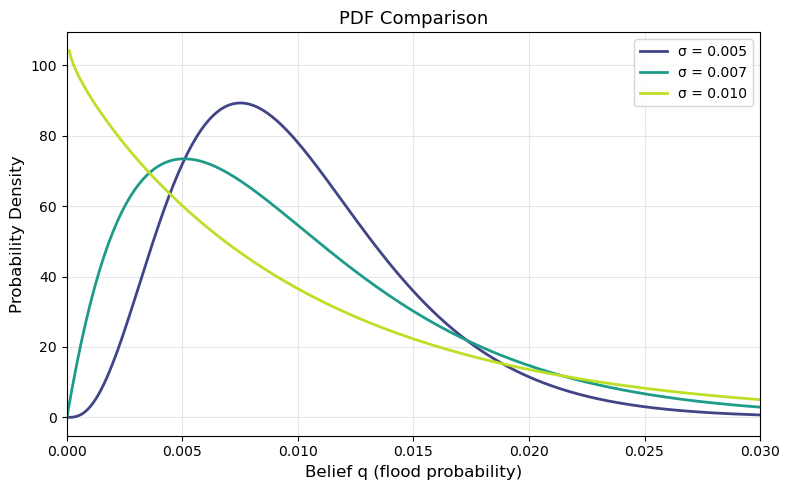

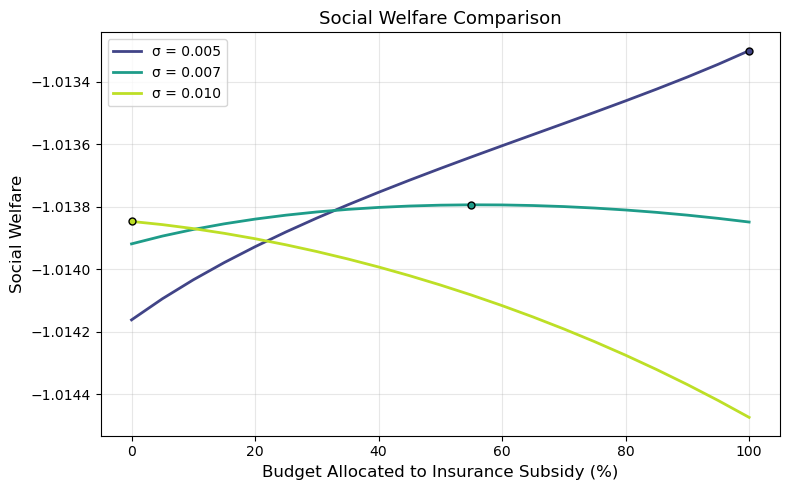

In [2]:
# Compare results across different belief variances
variances = [0.005**2, 0.007**2, 0.01**2]
mean_q = 0.01

# Create parameter sets
par_list = [Parameters(mean_q=mean_q, var_q=var, pi=0.02, gamma=2, B=0.001) for var in variances]
labels = [f'σ = {var**0.5:.3f}' for var in variances]

print("=" * 70)
print(f"{'COMPARISON ACROSS BELIEF VARIANCES':^70}")
print(f"Mean belief: {mean_q:.2%}")
print("=" * 70)

# Analyze each parameterization
results_list = []
for i, (par, var) in enumerate(zip(par_list, variances)):
    print(f"\n{'─' * 70}")
    print(f"Configuration {i+1}: σ² = {var:.6f}")
    print(f"{'─' * 70}")
    print(f"  Beta parameters:      α = {par.alpha:.2f}, β = {par.beta:.2f}")
    
    # No intervention outcomes
    outcomes_nogov = compute_outcomes(0., 0., par)
    print(f"\n  WITHOUT INTERVENTION:")
    print(f"    Insurance threshold (q*): {outcomes_nogov['q_star']:.2%}")
    print(f"    Fraction insured:         {outcomes_nogov['frac_insured']:.1%}")
    print(f"    Social welfare:           {outcomes_nogov['welfare']:.6f}")
    
    # Optimal policy
    s_opt, a_opt, lam_opt, converged = solve_optimal_policy(par)
    outcomes = compute_outcomes(s_opt, a_opt, par)
    
    print(f"\n  OPTIMAL POLICY:")
    print(f"    Subsidy (s):              {s_opt:.1%}")
    print(f"    Relief (a):               {a_opt:.1%}")
    print(f"    Shadow value (λ):         {lam_opt:.6f}")
    
    print(f"\n  OUTCOMES WITH OPTIMAL POLICY:")
    print(f"    Insurance threshold (q*): {outcomes['q_star']:.2%}")
    print(f"    Fraction insured:         {outcomes['frac_insured']:.1%}")
    print(f"    Social welfare:           {outcomes['welfare']:.6f}")
    print(f"    Welfare gain:             {outcomes['welfare'] - outcomes_nogov['welfare']:.6f}")
    
    # Compute welfare vs budget allocation for comparison
    results = compute_welfare_vs_budget_allocation(par, n_points=21)
    results_list.append(results)

print(f"\n{'=' * 70}")

# Compare distributions
print("\nGenerating comparison plots...")
fig1, ax1 = compare_beta_distributions(par_list, labels=labels, max_q=0.03)
#plt.savefig("pdf_comparison.png")

# Compare welfare functions
fig2, ax2 = compare_welfare_vs_budget_allocation(results_list, labels=labels)
#plt.savefig("welfare_comparison.png")


σ = 0.005  —  optimal: 100% → subsidy
  MVPF_s at optimal = 2.2291
  MVPF_a at optimal = -0.0183
  Internality (ic_s) at optimal = 0.010426
  Direct benefit (db_s) at opt  = 0.005835


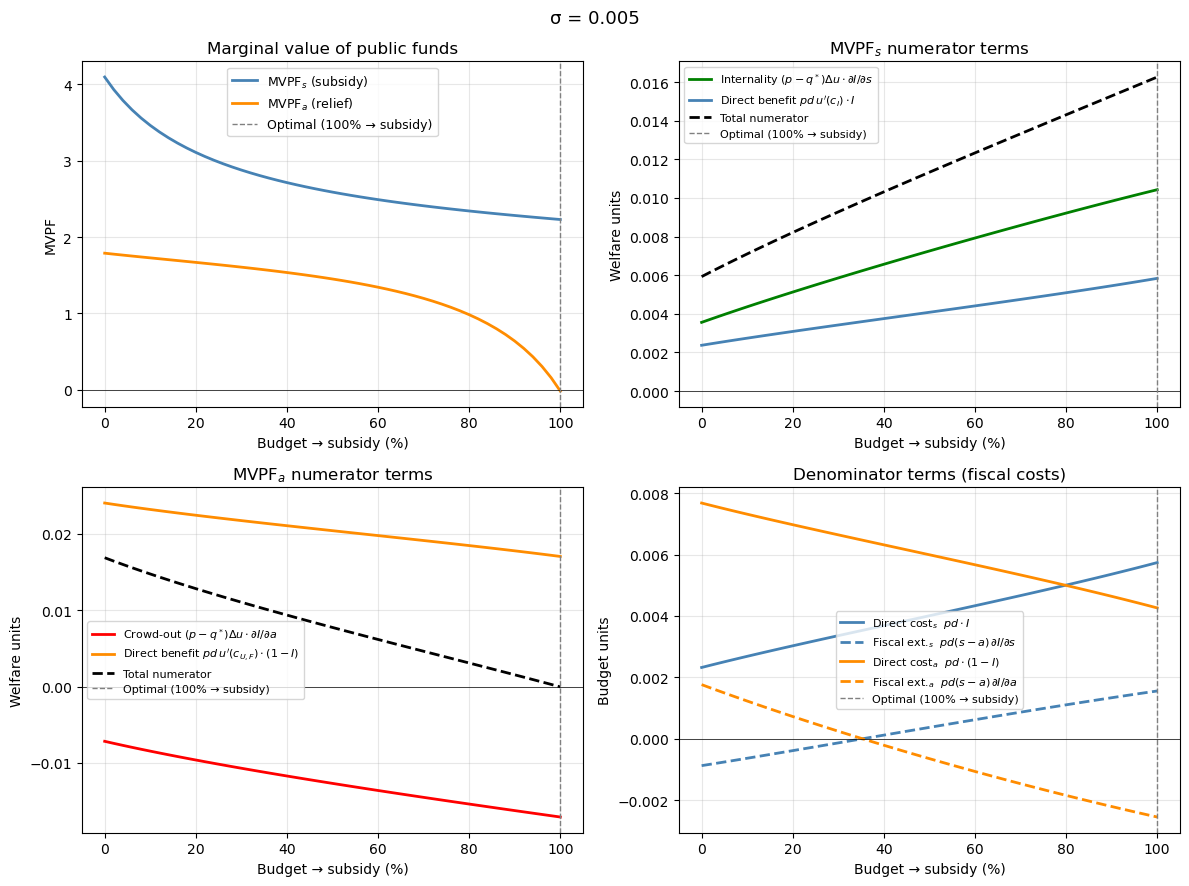


σ = 0.007  —  optimal: 56% → subsidy
  MVPF_s at optimal = 2.1518
  MVPF_a at optimal = 2.1504
  Internality (ic_s) at optimal = 0.005472
  Direct benefit (db_s) at opt  = 0.004107


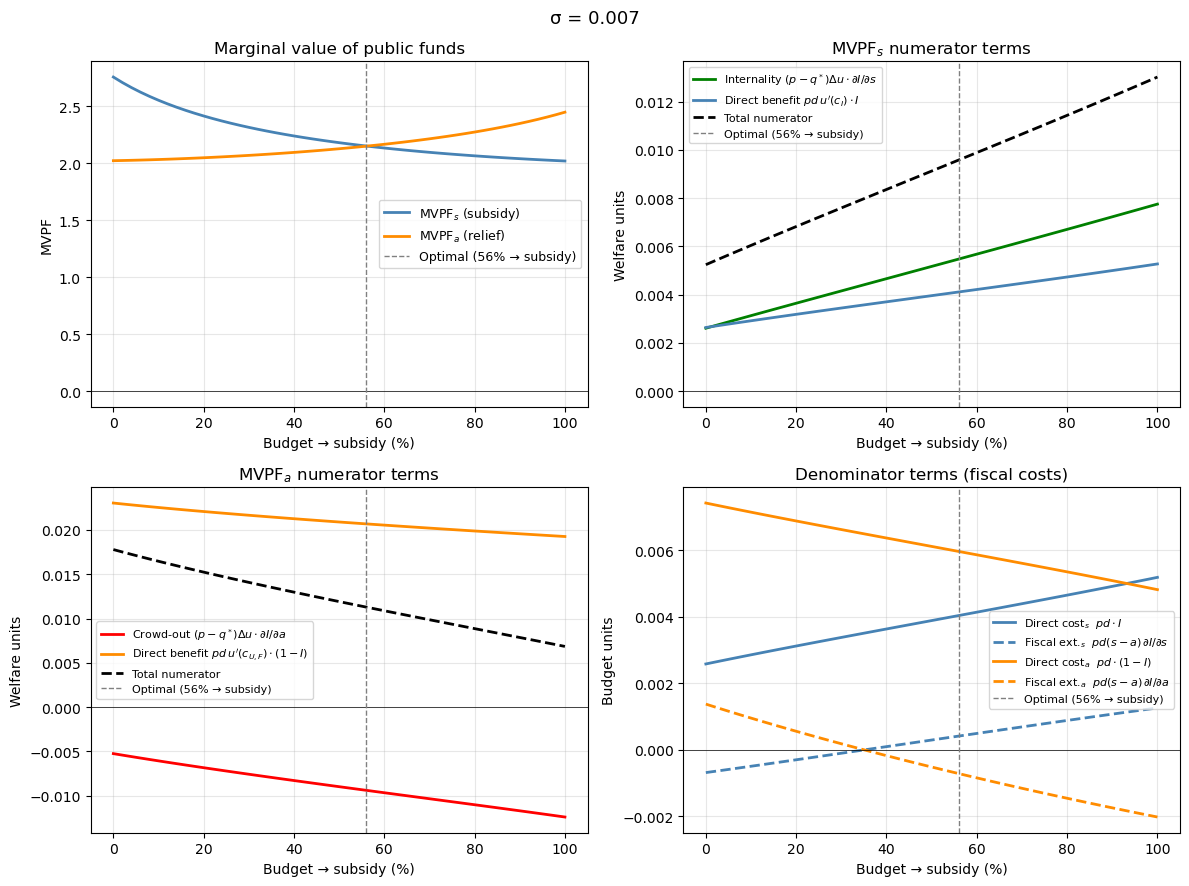


σ = 0.010  —  optimal: 0% → subsidy
  MVPF_s at optimal = 2.0776
  MVPF_a at optimal = 2.2967
  Internality (ic_s) at optimal = 0.001808
  Direct benefit (db_s) at opt  = 0.002713


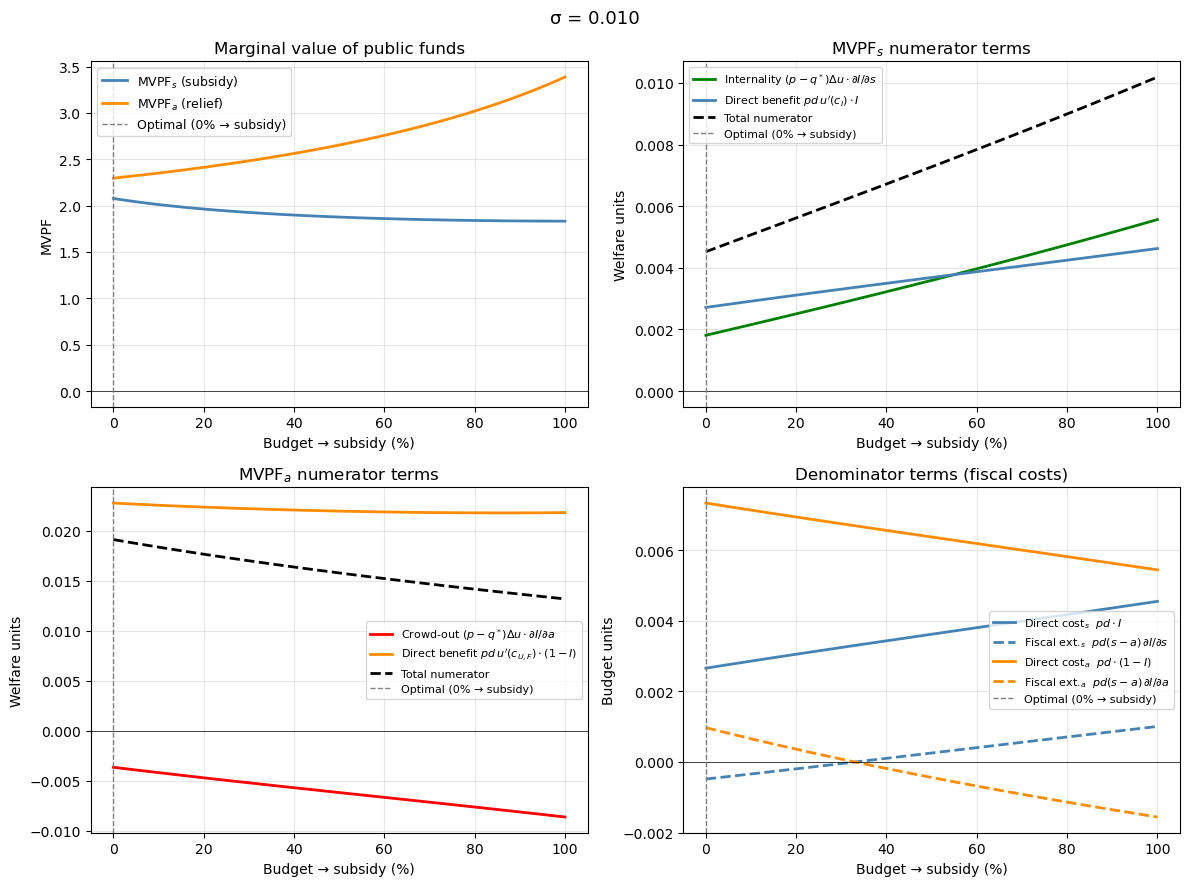

In [3]:
# MVPF decomposition along the budget frontier for each belief distribution
#
# For each budget-to-subsidy fraction, the (s, a) pair on the budget constraint
# is recovered, and both MVPFs are computed analytically from the beta PDF.
# The optimal allocation is the fraction that maximises welfare (same as the
# welfare plot above); at an interior optimum MVPF_s = MVPF_a = λ there.

for par, label in zip(par_list, labels):
    mvpf_data = compute_mvpfs_along_frontier(par, n_points=51)

    opt_idx = int(np.argmax(mvpf_data['welfare_values']))
    pct_opt = mvpf_data['fractions'][opt_idx] * 100

    print(f"\n{label}  —  optimal: {pct_opt:.0f}% → subsidy")
    print(f"  MVPF_s at optimal = {mvpf_data['MVPF_s'][opt_idx]:.4f}")
    print(f"  MVPF_a at optimal = {mvpf_data['MVPF_a'][opt_idx]:.4f}")
    print(f"  Internality (ic_s) at optimal = {mvpf_data['ic_s'][opt_idx]:.6f}")
    print(f"  Direct benefit (db_s) at opt  = {mvpf_data['db_s'][opt_idx]:.6f}")

    fig, axes = plot_mvpf_decomposition(mvpf_data, label=label)
    plt.show()


  Empirical  (d/w = 0.15)
  q* = 0.0096   p = 0.0200   (p - q*) = 0.0104
  dI/ds = 0.000153   dI/da = -0.000100

  MVPF_s = (0.00000 + 0.00090) / (0.00090 + 0.00000) = 1.0033
  MVPF_a = (-0.00000 + 0.00285) / (0.00210 + -0.00000) = 1.3576
  => Marginal dollar should go to disaster relief


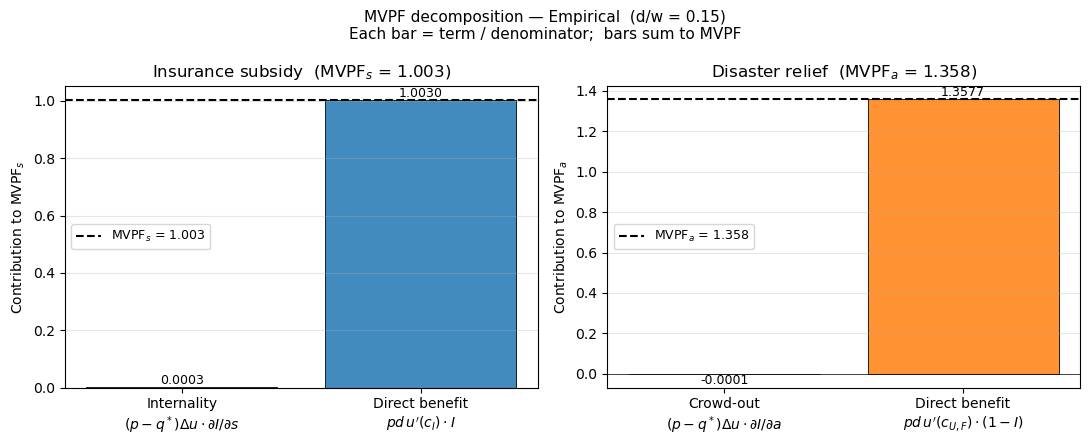


  Model  (d/w = 0.50)
  q* = 0.0059   p = 0.0200   (p - q*) = 0.0141
  dI/ds = 0.000510   dI/da = -0.000539

  MVPF_s = (0.00001 + 0.00303) / (0.00300 + 0.00000) = 1.0121
  MVPF_a = (-0.00001 + 0.02516) / (0.00700 + -0.00000) = 3.5940
  => Marginal dollar should go to disaster relief


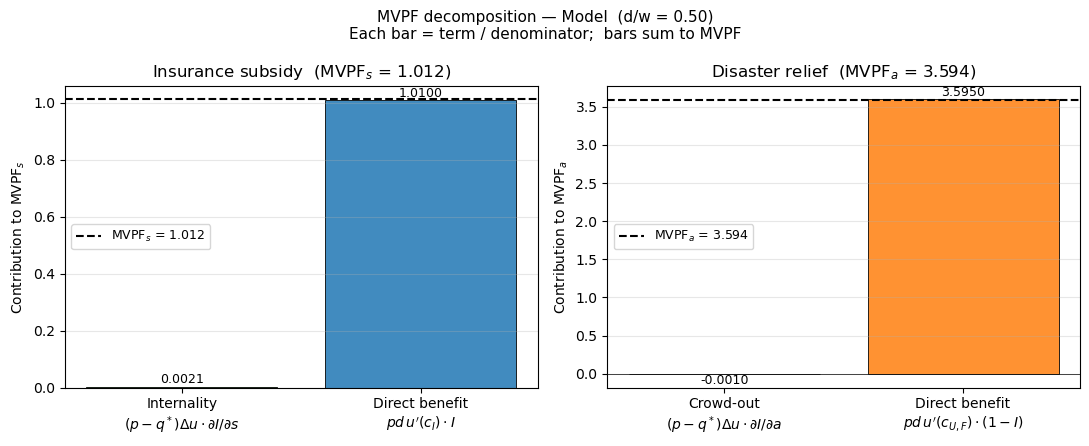

In [4]:
# Empirical calibration: MVPF decomposition at current US flood policy
#
# This mirrors compute_mvpfs.py but shows each sub-term visually so the mapping
# from the theoretical formulas (eq. 5–6) to the empirical numbers is transparent.
#
# Key difference from the model-based cells above: dI/ds here comes from the
# observed price semi-elasticity ε (Mulder 2021) rather than the beta PDF,
# because we do not observe the full belief distribution at current policy.
# dI/da is then recovered via the ratio trick (eq. 7), which cancels f(q*).
#
# Sources: GAO 2023 (s), FEMA (I), Mulder 2021 (ε), Chetty 2006 (γ)

from optimal_policy import u, u_prime

# ── Parameters ──────────────────────────────────────────────────────────────
s_emp   = 0.47      # current NFIP subsidy rate
a_emp   = 0.055     # avg FEMA IA grant / avg NFIP claim
I_emp   = 0.30      # take-up in high-risk areas
epsilon = -0.17     # price semi-elasticity of take-up w.r.t. premium
p_emp   = 0.02      # true flood probability
gamma   = 2.0       # CRRA risk aversion

for d_w, calib_label in [(0.15, 'Empirical  (d/w = 0.15)'), (0.50, 'Model  (d/w = 0.50)')]:
    w, d = 1.0, d_w
    pd = p_emp * d

    c_I   = w - (1 - s_emp) * pd
    c_U_F = w - (1 - a_emp) * d

    Delta_u = u(w, gamma) - u(c_U_F, gamma)
    qs = (u(w, gamma) - u(c_I, gamma)) / Delta_u

    du_I  = u_prime(c_I,   gamma)
    du_UF = u_prime(c_U_F, gamma)

    # Behavioral responses  (epsilon-based, ratio trick for dI/da)
    dI_ds = -pd * I_emp * epsilon                          # > 0
    dI_da = -(qs / p_emp) * (du_UF / du_I) * dI_ds        # < 0  [eq. 7]

    internality = (p_emp - qs) * Delta_u                   # [eq. 4]

    # MVPF_s sub-terms  [eq. 5]
    ic_s = internality * dI_ds
    db_s = pd * du_I  * I_emp
    dc_s = pd * I_emp
    fe_s = pd * (s_emp - a_emp) * dI_ds

    # MVPF_a sub-terms  [eq. 6]
    co_a = internality * dI_da
    db_a = pd * du_UF * (1 - I_emp)
    dc_a = pd * (1 - I_emp)
    fe_a = pd * (s_emp - a_emp) * dI_da

    MVPF_s = (ic_s + db_s) / (dc_s + fe_s)
    MVPF_a = (co_a + db_a) / (dc_a + fe_a)

    print(f"\n{'='*55}")
    print(f"  {calib_label}")
    print(f"{'='*55}")
    print(f"  q* = {qs:.4f}   p = {p_emp:.4f}   (p - q*) = {p_emp - qs:.4f}")
    print(f"  dI/ds = {dI_ds:.6f}   dI/da = {dI_da:.6f}")
    print(f"\n  MVPF_s = ({ic_s:.5f} + {db_s:.5f}) / ({dc_s:.5f} + {fe_s:.5f}) = {MVPF_s:.4f}")
    print(f"  MVPF_a = ({co_a:.5f} + {db_a:.5f}) / ({dc_a:.5f} + {fe_a:.5f}) = {MVPF_a:.4f}")
    if MVPF_a > MVPF_s:
        print("  => Marginal dollar should go to disaster relief")
    else:
        print("  => Marginal dollar should go to insurance subsidy")

    # ── Visual breakdown: contribution of each sub-term to the MVPF ─────────
    # MVPF = (term1 + term2) / denominator  =>  term_i / denominator is its
    # additive contribution to the MVPF.  Contributions sum to the MVPF.
    den_s = dc_s + fe_s
    den_a = dc_a + fe_a
    contribs_s = [ic_s / den_s, db_s / den_s]
    contribs_a = [co_a / den_a, db_a / den_a]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(f'MVPF decomposition — {calib_label}\n'
                 r'Each bar = term / denominator;  bars sum to MVPF', fontsize=11)

    # Subsidy
    ax = axes[0]
    clrs_s = ['#2ca02c', '#1f77b4']
    bars = ax.bar(['Internality\n' r'$(p-q^*)\Delta u\cdot\partial I/\partial s$',
                   "Direct benefit\n" r"$pd\,u'(c_I)\cdot I$"],
                  contribs_s, color=clrs_s, alpha=0.85, edgecolor='black', linewidth=0.7)
    ax.axhline(MVPF_s, color='black', lw=1.5, ls='--', label=f'MVPF$_s$ = {MVPF_s:.3f}')
    ax.axhline(0, color='black', lw=0.5)
    for bar, val in zip(bars, contribs_s):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002 * np.sign(val),
                f'{val:.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    ax.set_ylabel('Contribution to MVPF$_s$')
    ax.set_title(f'Insurance subsidy  (MVPF$_s$ = {MVPF_s:.3f})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # Disaster relief
    ax = axes[1]
    clrs_a = ['#d62728', '#ff7f0e']
    bars = ax.bar(['Crowd-out\n' r'$(p-q^*)\Delta u\cdot\partial I/\partial a$',
                   "Direct benefit\n" r"$pd\,u'(c_{U,F})\cdot(1-I)$"],
                  contribs_a, color=clrs_a, alpha=0.85, edgecolor='black', linewidth=0.7)
    ax.axhline(MVPF_a, color='black', lw=1.5, ls='--', label=f'MVPF$_a$ = {MVPF_a:.3f}')
    ax.axhline(0, color='black', lw=0.5)
    for bar, val in zip(bars, contribs_a):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002 * np.sign(val),
                f'{val:.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    ax.set_ylabel('Contribution to MVPF$_a$')
    ax.set_title(f'Disaster relief  (MVPF$_a$ = {MVPF_a:.3f})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()